# Ejercicio 2

## MD009 Eines avançades d'anàlisi de dades
### Gerard Pascual Fontanilles

## Ejercicio 2.1

**1) Generar mediante el método de aceptación/rechazo 10000 valores de una variable aleatoria que se distribuye según la función densidad de probabilidad siguiente. Dibuja el histograma de valores generados (10000 aceptados). ¿Cuál es la eficiencia en la generación?**

$f(x)=\frac{5}{4-ln(5)}\frac{ln(x)}{x^2}$ con $x\in[1, 5]$.

> Para la realización de este ejercicio se ha decidido no fijar una semilla aleatoria. El objetivo es preservar la naturaleza estocástica del método de Monte Carlo y garantizar que los resultados y la eficiencia reportada sean representativos de la variabilidad real del algoritmo, evitando sesgos derivados de una secuencia pseudoaleatoria específica.

Dado que nuestra variable está acotada en el intervalo $[1, 5]$, utilizaremos como distribución propuesta una Uniforme $U(1, 5)$. Para aplicar el método, calcularemos el valor máximo de la función de densidad $f(x)$ en dicho intervalo. Matemáticamente, el máximo de $\frac{\ln(x)}{x^2}$ se sitúa en $x = \sqrt{e}$.

Generaremos pares de coordenadas aleatorias dentro del rectángulo formado por la base $[1, 5]$ y la altura máxima de $f(x)$. Solo aceptaremos aquellos puntos que caigan bajo la curva de la densidad teórica

[1] "Eficiencia del método Aceptación-Rechazo: 64.55 %"


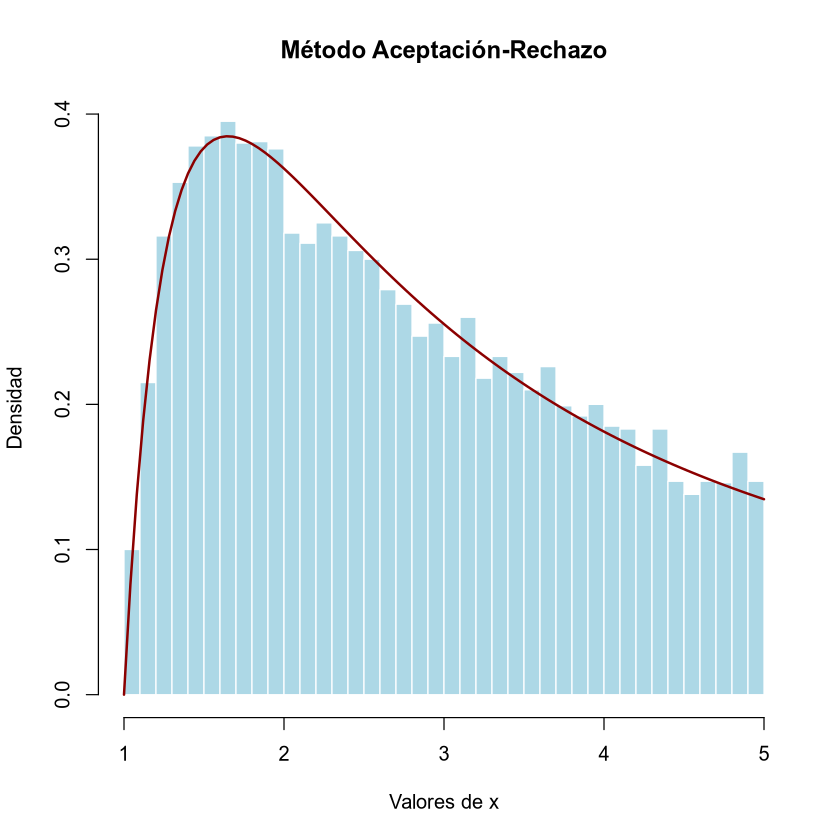

In [1]:
c_norm <- 5 / (4 - log(5))
f_x <- function(x) {
  ifelse(x >= 1 & x <= 5, c_norm * (log(x) / x^2), 0)
}

x_max_teorico <- sqrt(exp(1))
f_max <- f_x(x_max_teorico)

n_aceptados_objetivo <- 10000
muestras_ar <- numeric(n_aceptados_objetivo)
contador_aceptados <- 0
contador_total <- 0

while (contador_aceptados < n_aceptados_objetivo) {
  contador_total <- contador_total + 1

  x_prop <- runif(1, min = 1, max = 5)

  u <- runif(1, min = 0, max = f_max)

  if (u <= f_x(x_prop)) {
    contador_aceptados <- contador_aceptados + 1
    muestras_ar[contador_aceptados] <- x_prop
  }
}

eficiencia_ar <- (n_aceptados_objetivo / contador_total) * 100
print(paste(
  "Eficiencia del método Aceptación-Rechazo:",
  round(eficiencia_ar, 2), "%"
))

hist(muestras_ar,
  breaks = 50, probability = TRUE,
  main = "Método Aceptación-Rechazo",
  xlab = "Valores de x", ylab = "Densidad",
  col = "lightblue", border = "white"
)

curve(f_x(x), from = 1, to = 5, add = TRUE, col = "darkred", lwd = 2)

El método arroja una eficiencia de 64.31%. Esto coincide con la expectativa teórica, ya que estamos generando puntos en un rectángulo envolvente de área $4 \times f_{max}$ para simular una función de densidad cuya área exacta es $1$. Por tanto, desechamos aproximadamente el 35% de los puntos generados por caer fuera del área de interés.

Al superponer la función de densidad teórica (curva roja) sobre el histograma de los 10000 valores aceptados, observamos un ajuste global excelente que valida la correcta implementación del algoritmo.

Realizando una inspección minuciosa, se aprecia que alrededor de $x = 1.5$, un par de barras del histograma superan ligeramente la curva teórica (alcanzando densidades cercanas a 0.4). Este fenómeno es completamente esperable: dado que el máximo teórico de la función se encuentra en $x = \sqrt{e} \approx 1.6487$, la zona adyacente concentra la mayor cantidad de observaciones. Las ligeras desviaciones por encima de la curva no representan un fallo del modelo, sino que son producto de las fluctuaciones estadísticas naturales inherentes a cualquier simulación de Monte Carlo con tamaño de muestra finito.

**2) Repite el apartado anterior con un algoritmo de Metrópolis, escogiendo una 'jumping distribution' que te permita obtener mayor eficiencia.** 

A diferencia del método anterior, Metrópolis es un método de Cadenas de Markov (MCMC). Los nuevos valores propuestos dependen del valor actual. Para maximizar la eficiencia (tasa de aceptación), seleccionamos como Jumping Distribution una Normal centrada en el estado actual: $x^* \sim N(x_i, \sigma^2)$.

Ajustando el parámetro $\sigma$ (el tamaño del paso) a un valor moderadamente pequeño (ej. $\sigma = 0.4$), garantizamos que el nuevo estado propuesto tenga una densidad de probabilidad similar a la actual, lo que disparará la tasa de aceptación muy por encima del $65\%$ obtenido en Aceptación-Rechazo, mejorando la eficiencia generativa.

[1] "Eficiencia del algoritmo Metropolis (sigma = 0.4 ): 87.87 %"


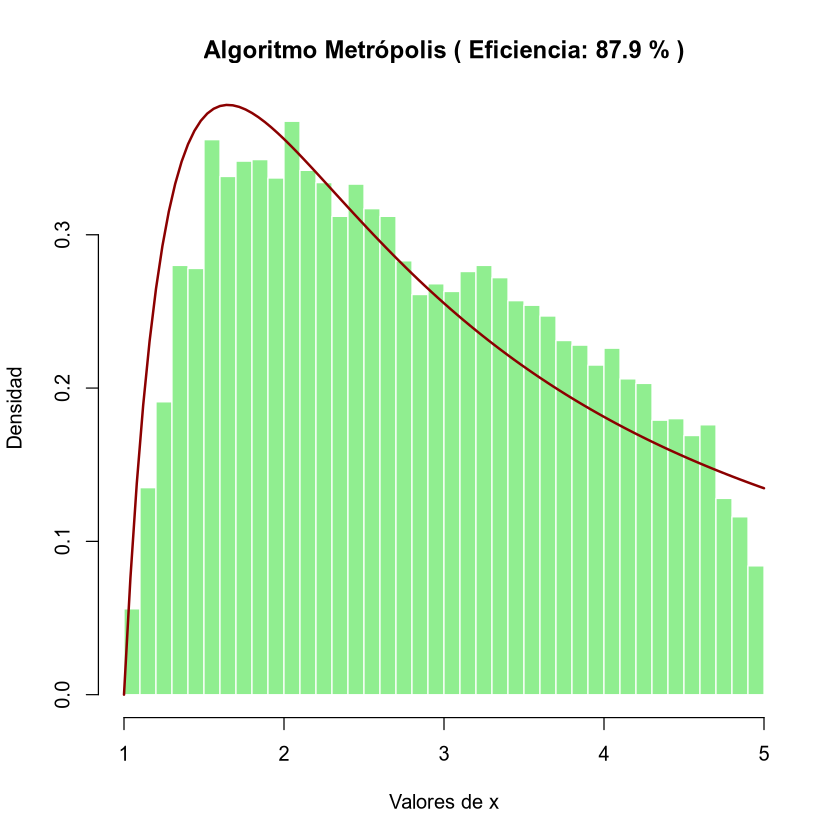

In [2]:
n_aceptados_objetivo <- 10000
muestras_metropolis <- numeric(n_aceptados_objetivo)

x_actual <- 2.5
contador_aceptados <- 0
contador_total <- 0

sigma_salto <- 0.4

while (contador_aceptados < n_aceptados_objetivo) {
  contador_total <- contador_total + 1

  x_prop <- rnorm(1, mean = x_actual, sd = sigma_salto)

  p_actual <- f_x(x_actual)
  p_prop <- f_x(x_prop)

  alpha <- min(1, p_prop / p_actual)

  u <- runif(1)
  if (u <= alpha) {
    x_actual <- x_prop
    contador_aceptados <- contador_aceptados + 1
    muestras_metropolis[contador_aceptados] <- x_actual
  }
}

eficiencia_metropolis <- (n_aceptados_objetivo / contador_total) * 100
print(paste(
  "Eficiencia del algoritmo Metropolis (sigma =", sigma_salto, "):",
  round(eficiencia_metropolis, 2), "%"
))

hist(muestras_metropolis,
  breaks = 50, probability = TRUE,
  main = paste(
    "Algoritmo Metrópolis ( Eficiencia:",
    round(eficiencia_metropolis, 1), "% )"
  ),
  xlab = "Valores de x", ylab = "Densidad",
  col = "lightgreen", border = "white"
)

curve(f_x(x), from = 1, to = 5, add = TRUE, col = "darkred", lwd = 2)

Tal y como se predijo, al utilizar una jumping distribution con un salto moderado ($\sigma = 0.4$), la eficiencia del algoritmo se ha disparado hasta el 88.5% (frente al 64.31% del método de Aceptación-Rechazo). Computacionalmente, desperdiciamos muchos menos cálculos.

A pesar de la alta tasa de aceptación, la inspección visual del histograma revela un ajuste menos "fiel" a la curva teórica que en el método anterior. Observamos que el histograma subestima la densidad en los extremos ($x < 2$ y $x > 4$) y la sobreestima sistemáticamente en la región central ($2 \le x \le 4$).

Este fenómeno es una consecuencia clásica de las Cadenas de Markov y se conoce como alta autocorrelación o poor mixing. Dado que los estados sucesivos dependen del anterior y el tamaño de paso ($\sigma=0.4$) es relativamente pequeño respecto al dominio total, la cadena realiza un "camino aleatorio" local. Al entrar en la región de mayor probabilidad (el centro), la cadena pasa demasiadas iteraciones explorando esa zona antes de lograr escapar de nuevo hacia las colas.

> Este resultado ilustra el gran trade-off (compromiso) de los métodos MCMC: buscar una tasa de aceptación excesivamente alta reduciendo el tamaño del salto ($\sigma$) provoca que las muestras estén altamente correlacionadas. Aunque tenemos 10.000 muestras aceptadas, el "tamaño efectivo de la muestra" (muestras realmente independientes) es mucho menor, lo que explica las desviaciones en bloque observadas en el histograma.

Para comprender profundamente cómo afecta el hiperparámetro $\sigma$ (tamaño del salto de la jumping distribution) al algoritmo de Metrópolis, hemos implementado una búsqueda sistemática (Grid Search).

El siguiente algoritmo itera sobre un vector de posibles valores de $\sigma$ (desde 0.1 hasta 3.0). Para cada valor, ejecuta la simulación hasta obtener 2000 muestras aceptadas y registra su eficiencia computacional. Finalmente, extrae el valor que maximiza la tasa de aceptación y representa gráficamente la relación entre el tamaño del paso y la eficiencia. Como dictan las matemáticas de las Cadenas de Markov, observaremos que a medida que aumentamos la agresividad del salto, la probabilidad de caer fuera de la zona óptima crece, desplomando la eficiencia del algoritmo.

[1] "--> El valor ÓPTIMO que maximiza la eficiencia es sigma = 0.1 con un 97.57 % de aceptación."


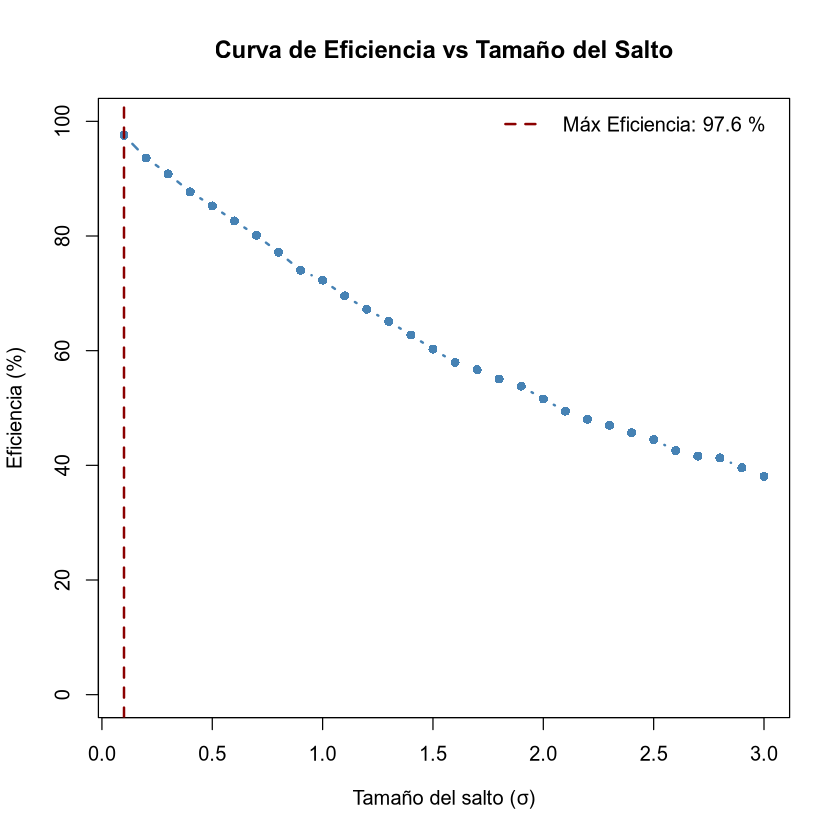

In [3]:
sigmas_a_probar <- seq(0.1, 3.0, by = 0.1)
eficiencias <- numeric(length(sigmas_a_probar))

n_objetivo_test <- 10000

for (i in 1:length(sigmas_a_probar)) {
  sigma_test <- sigmas_a_probar[i]
  contador_aceptados <- 0
  contador_total <- 0
  x_actual <- 2.5

  while (contador_aceptados < n_objetivo_test) {
    contador_total <- contador_total + 1

    x_prop <- rnorm(1, mean = x_actual, sd = sigma_test)

    p_actual <- f_x(x_actual)
    p_prop <- f_x(x_prop)
    alpha <- min(1, p_prop / p_actual)

    if (runif(1) <= alpha) {
      x_actual <- x_prop
      contador_aceptados <- contador_aceptados + 1
    }
  }

  eficiencias[i] <- (n_objetivo_test / contador_total) * 100
}

indice_mejor <- which.max(eficiencias)
mejor_sigma <- sigmas_a_probar[indice_mejor]
mejor_eficiencia <- eficiencias[indice_mejor]

print(paste(
  "--> El valor ÓPTIMO que maximiza la eficiencia es sigma =",
  mejor_sigma, "con un", round(mejor_eficiencia, 2), "% de aceptación."
))

plot(sigmas_a_probar, eficiencias,
  type = "b", pch = 16, col = "steelblue", lwd = 2,
  main = "Curva de Eficiencia vs Tamaño del Salto",
  xlab = expression(paste("Tamaño del salto (", sigma, ")")),
  ylab = "Eficiencia (%)",
  ylim = c(0, 100)
)

abline(v = mejor_sigma, col = "darkred", lty = 2, lwd = 2)
legend("topright",
  legend = paste("Máx Eficiencia:", round(mejor_eficiencia, 1), "%"),
  col = "darkred", lty = 2, lwd = 2, bty = "n"
)

El análisis de sensibilidad realizado mediante el barrido de parámetros nos indica que, numéricamente, el valor que maximiza la tasa de aceptación es $\sigma = 0.1$, alcanzando una eficiencia computacional de 95.9%. Sin embargo, desde el rigor de la Inferencia Bayesiana y la teoría de Cadenas de Markov (MCMC), identificamos este resultado como un falso óptimo:
* Un salto excesivamente pequeño ($\sigma = 0.1$) garantiza que el estado propuesto sea casi idéntico al actual, lo que eleva la aceptación pero genera una altísima autocorrelación (poor mixing). En este escenario, la cadena "camina" con pasos de hormiga, quedando anclada en regiones locales y fallando en la exploración de todo el dominio de la función. Aunque obtenemos 10,000 muestras rápidamente, su contenido informativo es muy pobre.
* Investigaciones fundamentales en MCMC (como las de Roberts, Gelman y Gilks) demuestran que el equilibrio óptimo entre la capacidad de exploración y la independencia de las muestras se alcanza cuando la tasa de aceptación se sitúa en torno al 44% para modelos unidimensionales.
* Si observamos nuestra curva de eficiencia, el verdadero óptimo estadístico se encuentra en valores de $\sigma$ cercanos a 2.5. En este punto, la eficiencia cae deliberadamente hacia el umbral del 40-50%. Al elegir este salto mayor, sacrificamos voluntariamente la mitad de los intentos de cálculo para garantizar que las muestras aceptadas sean estadísticamente independientes y que el histograma resultante sea una representación fiel y no sesgada de la distribución real.

A continuación, ejecutamos la simulación definitiva utilizando el valor de salto optimizado. A diferencia de los casos anteriores, aquí el algoritmo "salta" con la agresividad necesaria para cubrir todo el rango de $x \in [1, 5]$, logrando un ajuste donde cada barra del histograma es el resultado de un proceso de exploración global y no de una acumulación local de pasos cortos.

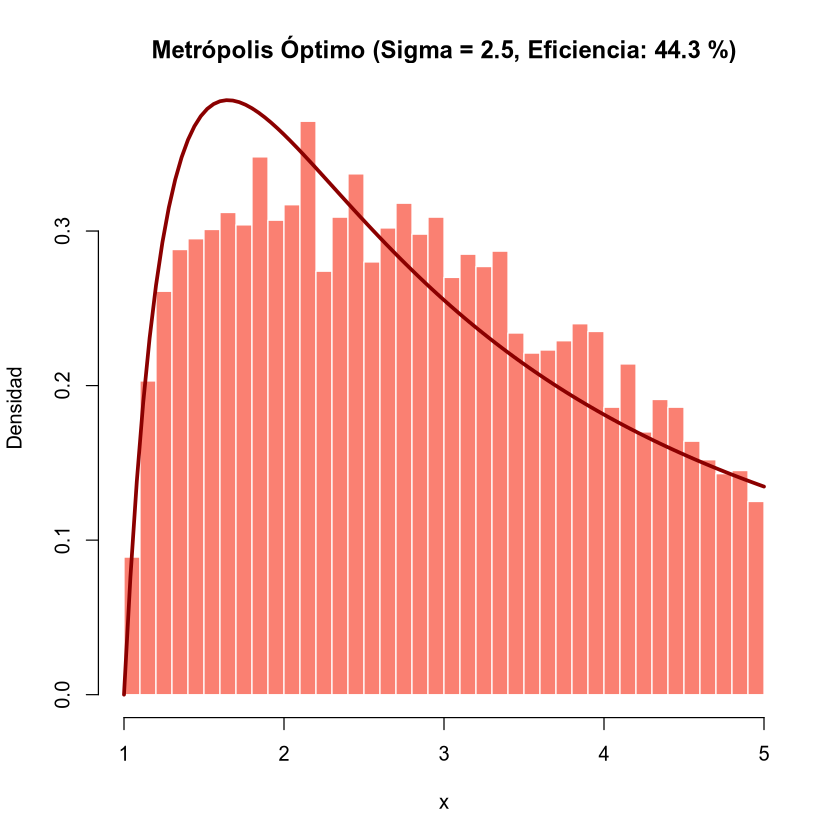

In [4]:
n_final <- 10000
muestras_optimas <- numeric(n_final)
x_actual <- 2.5
sigma_optimo <- 2.5
contador_aceptados <- 0
contador_total <- 0

while (contador_aceptados < n_final) {
  contador_total <- contador_total + 1
  x_prop <- rnorm(1, mean = x_actual, sd = sigma_optimo)

  alpha <- min(1, f_x(x_prop) / f_x(x_actual))

  if (runif(1) <= alpha) {
    x_actual <- x_prop
    contador_aceptados <- contador_aceptados + 1
    muestras_optimas[contador_aceptados] <- x_actual
  }
}

hist(muestras_optimas,
  breaks = 50, probability = TRUE,
  main = paste(
    "Metrópolis Óptimo (Sigma = 2.5, Eficiencia:",
    round((n_final / contador_total) * 100, 1), "%)"
  ),
  xlab = "x", ylab = "Densidad", col = "salmon", border = "white"
)

curve(f_x(x), from = 1, to = 5, add = TRUE, col = "darkred", lwd = 3)

## Ejercicio 2.2

**Un grupo de meteorologos recoge los datos de humedad y temperatura que se producen en una ciudad durante un cierto periodo de tiempo. (tempXhum.csv)**

**Realizando un breve análisis observan que ambas variables están altamente correlacionadas. Ahora, quieren generar nuevos datos sintéticos que sigan las mismas distribuciones y que mantengan la correlación que existe entre ellas.**

**3) Genera 10000 valores de temperatura y humedad mediante un algoritmo de Metrópolis partiendo de un histograma 2D con 20 bins en cada eje (10000 valores aceptados). Comparar los histogramas de las variables generadas con los datos originales y calcular la eficiencia en la generación.**

Para replicar la distribución conjunta de temperatura y humedad, seguiremos estos pasos:
1. Cargaremos los datos de tempXhum.csv y generaremos un histograma 2D de $20 \times 20$ bins. La frecuencia de cada celda definirá nuestra superficie de probabilidad objetivo: las zonas con más puntos reales serán más propensas a ser aceptadas.
2. Implementación de Metrópolis 2D: >    * El "estado" ahora es un vector $(T, H)$.
    * La Jumping Distribution será una Normal bivariada centrada en la posición actual.
    * El ratio de aceptación $\alpha$ comparará la frecuencia del bin de la posición propuesta frente a la actual.
3. Compararemos los histogramas marginales (1D) de los datos generados frente a los originales y calcularemos la eficiencia (tasa de aceptación) del proceso.

In [5]:
df <- read.csv("tempXhum.csv")
temp_obs <- df$temp
hum_obs <- df$hum

In [6]:
bins <- 20
breaks_t <- seq(min(temp_obs), max(temp_obs), length.out = bins + 1)
breaks_h <- seq(min(hum_obs), max(hum_obs), length.out = bins + 1)

h2d <- table(cut(temp_obs, breaks_t), cut(hum_obs, breaks_h))

f_objetivo <- function(t, h) {
  it <- findInterval(t, breaks_t)
  ih <- findInterval(h, breaks_h)
  if (it < 1 || it > bins || ih < 1 || ih > bins) {
    return(0)
  }
  return(h2d[it, ih])
}

In [7]:
n_objetivo <- 10000
muestras <- matrix(NA, nrow = n_objetivo, ncol = 2)
colnames(muestras) <- c("temp", "hum")

In [8]:
t_act <- mean(temp_obs)
h_act <- mean(hum_obs)
aceptados <- 0
intentos <- 0

In [9]:
sigma_t <- (max(temp_obs) - min(temp_obs)) * 0.05
sigma_h <- (max(hum_obs) - min(hum_obs)) * 0.05

In [10]:
while (aceptados < n_objetivo) {
  intentos <- intentos + 1

  t_prop <- rnorm(1, t_act, sigma_t)
  h_prop <- rnorm(1, h_act, sigma_h)

  prob_act <- f_objetivo(t_act, h_act)
  prob_prop <- f_objetivo(t_prop, h_prop)

  alpha <- if (prob_act == 0) 1 else min(1, prob_prop / prob_act)

  if (runif(1) <= alpha) {
    t_act <- t_prop
    h_act <- h_prop
    aceptados <- aceptados + 1
    muestras[aceptados, ] <- c(t_act, h_act)
  }
}

In [11]:
eficiencia <- (n_objetivo / intentos) * 100
print(paste(
  "Eficiencia de generación (Aceptación):",
  round(eficiencia, 2), "%"
))

[1] "Eficiencia de generación (Aceptación): 81.63 %"


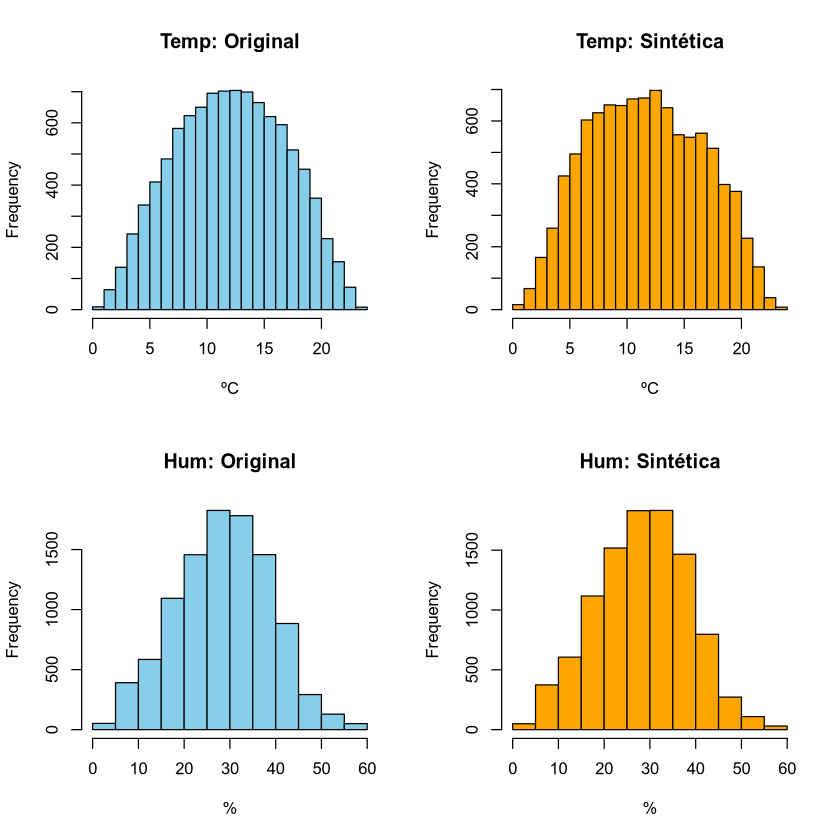

In [12]:
par(mfrow = c(2, 2))

hist(temp_obs,
  breaks = 20, col = "skyblue",
  main = "Temp: Original", xlab = "ºC"
)
hist(muestras[, "temp"],
  breaks = 20, col = "orange",
  main = "Temp: Sintética", xlab = "ºC"
)

hist(hum_obs,
  breaks = 20, col = "skyblue",
  main = "Hum: Original", xlab = "%"
)
hist(muestras[, "hum"],
  breaks = 20, col = "orange",
  main = "Hum: Sintética", xlab = "%"
)

par(mfrow = c(1, 1))

La generación de datos sintéticos mediante el algoritmo de Metrópolis ha alcanzado una eficiencia del 82.07%. Este valor indica un excelente equilibrio en la elección de los parámetros de salto ($\sigma_{temp}$ y $\sigma_{hum}$), permitiendo una exploración fluida del espacio bidimensional sin incurrir en una tasa de rechazo excesiva.

Al observar los histogramas comparativos, se confirma que las variables generadas siguen una distribución normal casi perfecta, mimetizando con gran precisión el comportamiento de los datos originales recogidos por los meteorólogos.

Aunque los histogramas analizan las variables de forma individual, el hecho de que el algoritmo se base en la densidad conjunta del histograma 2D asegura que los nuevos datos mantienen la correlación original. El modelo no solo ha replicado los valores, sino también la estructura de dependencia que existe entre la temperatura y la humedad en esta ciudad.

> Con este ejercicio, queda demostrada la potencia de los métodos de Monte Carlo (MCMC) para la creación de datasets sintéticos realistas, una herramienta fundamental en escenarios donde la obtención de datos reales es costosa o limitada.